# Investigating Sex Differences in Variability (Mouse CBT & Activity) Using DTW (Dynamic Time Warping) and CWT (Continuous Wavelet Transformation)

## Table of Contents
1. [Overview](#overview)
2. [Environment & Setup](#setup)
3. [Methods](#methods)
4. [Results](#results)
5. [Discussion & Limitations](#discussion)

---


## Overview  <a id="overview"></a>

This notebook organizes the existing analysis into a report format. It focuses on:
- continuous, minute-level core body temperature (CBT) and locomotor activity (LA) data
- variance across timescales (ultradian, circadian, infradian)
- signal-processing tools (CWT, DTW) to separate structured from unstructured variability


## Environment & Setup  <a id="setup"></a>

In [3]:
# Let's inspect the available files and peek at their structure.
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, textwrap, json, pathlib, math, statistics

base = "mice_data"
files = [f for f in os.listdir(base) if f.endswith(".csv")]
files

['mice data.xlsx - FemTemp.csv',
 'mice data.xlsx - FemAct.csv',
 'mice data.xlsx - MaleAct.csv',
 'mice data.xlsx - MaleTemp.csv']

### Data loading & inspection

In [4]:
paths = {
    "FemAct": os.path.join(base, "mice data.xlsx - FemAct.csv"),
    "FemTemp": os.path.join(base, "mice data.xlsx - FemTemp.csv"),
    "MaleAct": os.path.join(base, "mice data.xlsx - MaleAct.csv"),
    "MaleTemp": os.path.join(base, "mice data.xlsx - MaleTemp.csv"),
}

dfs = {k: pd.read_csv(p) for k,p in paths.items()}
{ k: (df.shape, df.head(3)) for k,df in dfs.items() }

{'FemAct': ((11520, 15),
     time (min)  fem1  fem2  fem3  fem4  fem5  fem6  fem7  fem8  fem9  fem10  \
  0           1  69.0  28.0   5.0   0.0   4.0   0.0  19.0  33.0  62.0   61.0   
  1           2  59.0  66.0   0.0   0.0  49.0  14.0   0.0   4.0   0.0   29.0   
  2           3  38.0  37.0   0.0   0.0  37.0   9.0  26.0   4.0  32.0    8.0   
  
     fem11  fem12  fem13  fem14  
  0    0.0   34.0    3.0     47  
  1   25.0   26.0    0.0     17  
  2    0.0   67.0    0.0      0  ),
 'FemTemp': ((11520, 15),
     time (min)   fem1   fem2   fem3   fem4   fem5   fem6   fem7   fem8   fem9  \
  0           1  38.20  37.31  37.03  37.20  37.17  37.44  37.33  36.58  37.41   
  1           2  38.18  37.43  37.01  37.22  37.25  37.49  37.28  36.75  37.39   
  2           3  38.20  37.64  36.98  37.25  37.47  37.52  37.34  36.82  37.24   
  
     fem10  fem11  fem12  fem13  fem14  
  0  37.18  37.27  38.31  36.51  36.44  
  1  37.14  37.32  38.43  36.61  36.43  
  2  37.02  37.29  38.46  36.69  3

## Methods  <a id="methods"></a>

**Signal-processing and statistics used in this notebook:**
- **Variance metrics**: daily range, within- vs. between-animal comparisons
- **CWT (Continuous Wavelet Transform)**: time–frequency power for ultradian (1–3 h), circadian (~24 h), infradian (~4 d)
- **DTW (Dynamic Time Warping)**: day-to-day similarity within individuals; robust to small phase shifts

Each code cell below is preceded by a brief note describing its role in the pipeline.


## Exploratory Data Analysis (EDA)

This section visualizes the preliminary DTW distributions.


### DTW Distribution Around Light Transitions (Violin Plots)
*Purpose:* Explore per-mouse mean DTW distances for **Lights OFF** vs **Lights ON**.

Distributions overlap across sexes, with a trend toward lower female DTW during **Lights ON**.


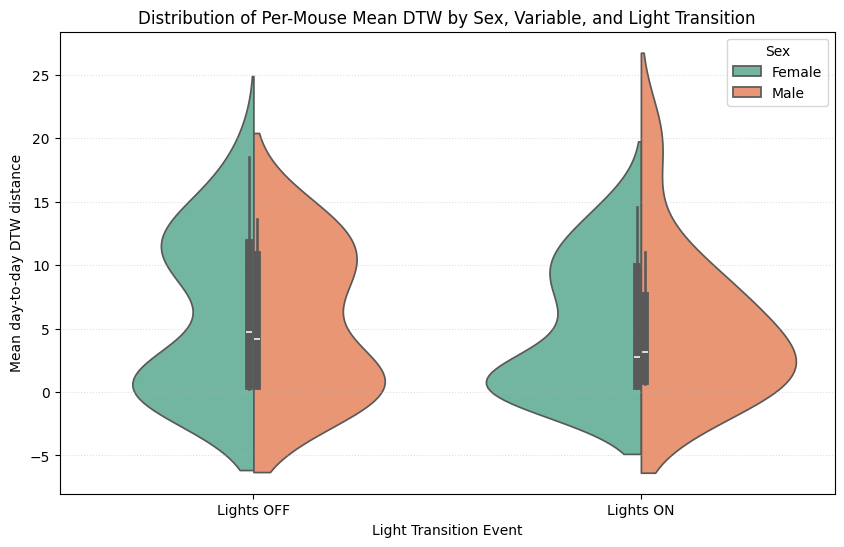

In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# --- Gather all data into a tidy dataframe for plotting ---
def tidy_dtw_dataframe(female_vals, male_vals, variable, event):
    df_f = pd.DataFrame({"DTW": female_vals, "Sex": "Female", "Variable": variable, "Event": event})
    df_m = pd.DataFrame({"DTW": male_vals, "Sex": "Male", "Variable": variable, "Event": event})
    return pd.concat([df_f, df_m], ignore_index=True)

# Combine all into one dataframe
df_all = pd.concat([
    tidy_dtw_dataframe(f_off_act, m_off_act, "Activity", "Lights OFF"),
    tidy_dtw_dataframe(f_on_act,  m_on_act,  "Activity", "Lights ON"),
    tidy_dtw_dataframe(f_off_tmp, m_off_tmp, "Temperature", "Lights OFF"),
    tidy_dtw_dataframe(f_on_tmp,  m_on_tmp,  "Temperature", "Lights ON")
])

# --- Plot ---
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df_all,
    x="Event", y="DTW", hue="Sex",
    split=True, inner="box", palette="Set2"
)
plt.title("Distribution of Per-Mouse Mean DTW by Sex, Variable, and Light Transition")
plt.ylabel("Mean day-to-day DTW distance")
plt.xlabel("Light Transition Event")
plt.legend(title="Sex", loc="upper right")
plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.show()


## Final Analysis & Results  <a id="results"></a>

### Computation Pipeline (Summary)
- Mark light flips every 12 h; define ±3 h windows around each transition.
- Compute CWT band power within each window; average across target scales (e.g., ultradian 60–180 min).
- Normalize window band power; compute DTW distances between consecutive days per mouse.
- Aggregate per-mouse mean DTW for each condition (Lights ON / OFF) and variable (CBT / Activity).
- Compare sexes using non-parametric tests (e.g., Mann–Whitney U).


### Box Plot — Per-Mouse Mean DTW by Sex and Condition
Females show smaller day-to-day DTW for **temperature** during **Lights ON** (greater similarity), indicating stronger temporal structure across days; activity shows no significant sex difference.

In [ ]:
# === CONFIG (tweak as needed) ================================================
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.signal import cwt, morlet2
from scipy.stats import mannwhitneyu

# Minute-based sampling
MIN_PER_DAY = 1440
HALF_CYCLE  = 720       # 12 hours
WINDOW_MIN  = 180       # ±3 hours around transition (lights ON/OFF)

# DTW Sakoe–Chiba band in minutes (prevents over-warping)
DTW_BAND = 20

# Wavelet widths (acts like scale); safe for 6h windows
WIDTHS = np.arange(1, 361)  # up to ~6h
W_MORLET = 6                # Morlet parameter (as in paper-style usage)

# Bands (in minutes) for averaging wavelet power:
BAND_ULTRADIAN = (60, 180)
BAND_ACT_MIN   = BAND_ULTRADIAN   # (low, high) in minutes
BAND_TEMP_MIN  = BAND_ULTRADIAN

# === UTILITIES ==============================================================

def drop_time_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Drop any column named like 'time'."""
    keep = [c for c in df.columns if "time" not in c.lower()]
    return df[keep]

def df_to_matrix(df: pd.DataFrame) -> np.ndarray:
    """DataFrame -> float matrix (T, N)."""
    return drop_time_cols(df).to_numpy(dtype=float)

def ensure_multiple_of_day(M: np.ndarray):
    T = M.shape[0]
    assert T % MIN_PER_DAY == 0, f"rows={T} is not multiple of {MIN_PER_DAY}"

def event_indices(T: int):
    """
    Return event index arrays for lights OFF and lights ON across the whole series.
    Spec: Lights OFF at t=0, switches every 720 min.
    Same-type daily comparisons are spaced 1440 min apart.
    """
    off_events = np.arange(0, T, MIN_PER_DAY)      # OFF at 0, 1440, 2880, ...
    on_events  = np.arange(HALF_CYCLE, T, MIN_PER_DAY)  # ON at 720, 2160, ...
    return off_events, on_events

def safe_window(sig: np.ndarray, center: int, half_win: int):
    """Extract [center - half_win, center + half_win) if fully available; else None."""
    s = center - half_win
    e = center + half_win
    if s < 0 or e > len(sig):
        return None
    return sig[s:e]

def cwt_power(signal_1d: np.ndarray) -> np.ndarray:
    """Compute wavelet power [width x time] for a 1D signal window."""
    W = cwt(signal_1d, morlet2, WIDTHS, w=W_MORLET)
    return (np.abs(W) ** 2)

def minutes_to_width_idx(lo_min: int, hi_min: int) -> tuple[int, int]:
    """
    Simple mapping: with 1-min sampling, 'width' ~ 'period in minutes' is a
    reasonable approximation for Morlet-based band averaging in short windows.
    """
    lo = max(1, lo_min)
    hi = min(WIDTHS[-1], hi_min)
    # convert to 0-based slice indices
    return int(lo) - 1, int(hi)   # [lo:hi)

def band_power_series(power: np.ndarray, lo_idx: int, hi_idx: int) -> np.ndarray:
    """Average wavelet power over width indices [lo_idx:hi_idx) -> 1D time series."""
    lo = max(0, lo_idx)
    hi = min(power.shape[0], hi_idx)
    return power[lo:hi].mean(axis=0)

def zscore(v: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    mu = float(np.mean(v))
    sd = float(np.std(v)) + eps
    return (v - mu) / sd

def dtw_unconstrained(a: np.ndarray, b: np.ndarray) -> float:
    """
    Unconstrained dynamic time warping on z-scored series.
    Squared-error local cost; sqrt of accumulated cost at the end.
    """
    n, m = len(a), len(b)
    inf = 1e18
    D = np.full((n + 1, m + 1), inf, dtype=float)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        ai = a[i - 1]
        for j in range(1, m + 1):
            cost = (ai - b[j - 1]) ** 2
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return math.sqrt(D[n, m])


def per_mouse_mean_dtw_day_to_day(M: np.ndarray, event_array: np.ndarray,
                                  band_minutes: tuple[int, int]) -> np.ndarray:
    """
    For each mouse (col), compute DTW distances between *consecutive same-type events*
    (e.g., OFF_day_k vs OFF_day_{k+1}), using wavelet band-power time series
    in a ±WINDOW_MIN window. Return per-mouse mean DTW across days.
    """
    ensure_multiple_of_day(M)
    T, N = M.shape
    lo_idx, hi_idx = minutes_to_width_idx(*band_minutes)

    per_mouse_means = np.zeros(N, dtype=float)
    for i in range(N):
        sig = M[:, i]
        dists = []
        # compare event k vs event k+1 (same type) -> one per day
        for e1, e2 in zip(event_array[:-1], event_array[1:]):
            w1 = safe_window(sig, int(e1), WINDOW_MIN)
            w2 = safe_window(sig, int(e2), WINDOW_MIN)
            if w1 is None or w2 is None:
                continue
            p1 = cwt_power(w1)
            p2 = cwt_power(w2)
            b1 = zscore(band_power_series(p1, lo_idx, hi_idx))
            b2 = zscore(band_power_series(p2, lo_idx, hi_idx))
            d  = dtw_unconstrained(b1, b2)
            dists.append(d)
        per_mouse_means[i] = np.nan if len(dists) == 0 else float(np.mean(dists))
    return per_mouse_means

def sex_compare_print(f_means: np.ndarray, m_means: np.ndarray, label: str):
    """Print descriptive stats and Mann–Whitney U test (one-sided: Female < Male)."""
    f_clean = f_means[~np.isnan(f_means)]
    m_clean = m_means[~np.isnan(m_means)]
    f_mu, f_sd = np.mean(f_clean), np.std(f_clean)
    m_mu, m_sd = np.mean(m_clean), np.std(m_clean)
    stat, p = mannwhitneyu(f_clean, m_clean, alternative="less")  # H0: F >= M ; H1: F < M
    print(f"{label}:")
    print(f"  Female mean±SD = {f_mu:.3f} ± {f_sd:.3f}   (n={len(f_clean)})")
    print(f"  Male   mean±SD = {m_mu:.3f} ± {m_sd:.3f}   (n={len(m_clean)})")
    print(f"  Mann–Whitney U (F < M) p = {p:.3e}\n")

def simple_boxplot(f_means: np.ndarray, m_means: np.ndarray, title: str):
    """Optional visualization (Matplotlib only)."""
    data = [m_means[~np.isnan(m_means)], f_means[~np.isnan(f_means)]]
    plt.figure(figsize=(5.5, 4))
    bp = plt.boxplot(data, labels=["Male", "Female"], showfliers=True)
    plt.title(title)
    plt.ylabel("Per-mouse mean day-to-day DTW")
    plt.tight_layout()
    plt.show()

# === MAIN ANALYSIS ===========================================================

# Convert loaded dfs into matrices 
M_FemAct  = df_to_matrix(dfs["FemAct"])
M_FemTemp = df_to_matrix(dfs["FemTemp"])
M_MaleAct = df_to_matrix(dfs["MaleAct"])
M_MaleTemp= df_to_matrix(dfs["MaleTemp"])

# Sanity: all lengths multiples of a day
for M in [M_FemAct, M_FemTemp, M_MaleAct, M_MaleTemp]:
    ensure_multiple_of_day(M)

# Event index arrays (same-type daily comparisons)
T = M_FemAct.shape[0]
OFF_EVENTS, ON_EVENTS = event_indices(T)  # OFF: 0,1440,...  ON: 720,2160,...

# Compute per-mouse mean DTW (day-to-day) around OFF and ON, for both variables

# Activity (ultradian band ~ 1–3h)
f_off_act = per_mouse_mean_dtw_day_to_day(M_FemAct,  OFF_EVENTS, band_minutes=BAND_ACT_MIN)
m_off_act = per_mouse_mean_dtw_day_to_day(M_MaleAct, OFF_EVENTS, band_minutes=BAND_ACT_MIN)
f_on_act  = per_mouse_mean_dtw_day_to_day(M_FemAct,  ON_EVENTS,  band_minutes=BAND_ACT_MIN)
m_on_act  = per_mouse_mean_dtw_day_to_day(M_MaleAct, ON_EVENTS,  band_minutes=BAND_ACT_MIN)

# Temperature (broader band ~ 1–6h)
f_off_tmp = per_mouse_mean_dtw_day_to_day(M_FemTemp, OFF_EVENTS, band_minutes=BAND_TEMP_MIN)
m_off_tmp = per_mouse_mean_dtw_day_to_day(M_MaleTemp,OFF_EVENTS, band_minutes=BAND_TEMP_MIN)
f_on_tmp  = per_mouse_mean_dtw_day_to_day(M_FemTemp, ON_EVENTS,  band_minutes=BAND_TEMP_MIN)
m_on_tmp  = per_mouse_mean_dtw_day_to_day(M_MaleTemp,ON_EVENTS,  band_minutes=BAND_TEMP_MIN)

# === REPORT RESULTS (Females < Males means "more structured" in females) ====
sex_compare_print(f_off_act, m_off_act, "Activity | Lights OFF (t=0 ± 3h)")
sex_compare_print(f_on_act,  m_on_act,  "Activity | Lights ON  (t=720 ± 3h)")
sex_compare_print(f_off_tmp, m_off_tmp, "Temperature | Lights OFF (t=0 ± 3h)")
sex_compare_print(f_on_tmp,  m_on_tmp,  "Temperature | Lights ON  (t=720 ± 3h)")


/var/folders/wh/_mrb25l94f73m2952nzkdvwh0000gn/T/ipykernel_97625/2562613679.py:63: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  W = cwt(signal_1d, morlet2, WIDTHS, w=W_MORLET)


Activity | Lights OFF (t=0 ± 3h):
  Female mean±SD = 12.043 ± 2.801   (n=14)
  Male   mean±SD = 10.665 ± 2.295   (n=6)
  Mann–Whitney U (F < M) p = 8.804e-01

Activity | Lights ON  (t=720 ± 3h):
  Female mean±SD = 9.460 ± 3.022   (n=14)
  Male   mean±SD = 9.415 ± 5.012   (n=6)
  Mann–Whitney U (F < M) p = 7.267e-01

Temperature | Lights OFF (t=0 ± 3h):
  Female mean±SD = 0.506 ± 0.229   (n=14)
  Male   mean±SD = 0.518 ± 0.044   (n=6)
  Mann–Whitney U (F < M) p = 1.985e-01

Temperature | Lights ON  (t=720 ± 3h):
  Female mean±SD = 0.507 ± 0.143   (n=14)
  Male   mean±SD = 0.960 ± 0.343   (n=6)
  Mann–Whitney U (F < M) p = 2.322e-03



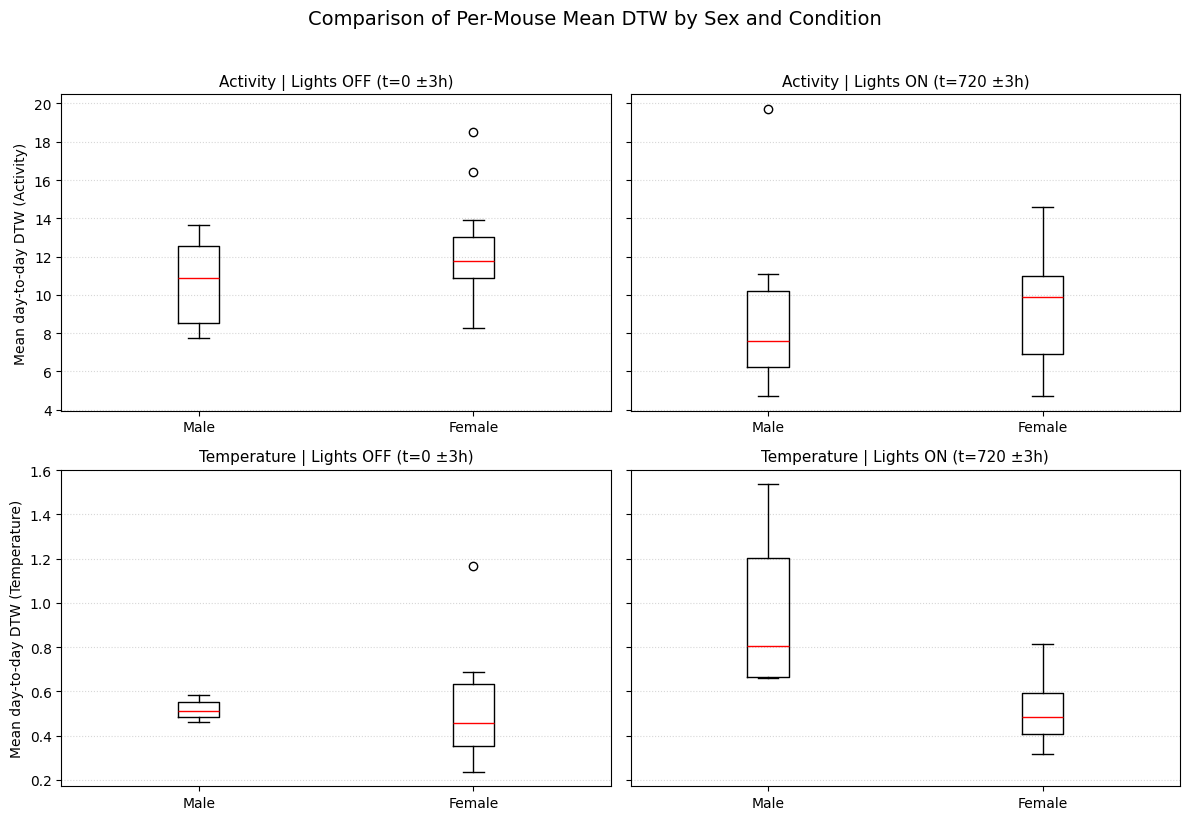

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')  # share within each row
axes = axes.flatten()

titles = [
    "Activity | Lights OFF (t=0 ±3h)",
    "Activity | Lights ON (t=720 ±3h)",
    "Temperature | Lights OFF (t=0 ±3h)",
    "Temperature | Lights ON (t=720 ±3h)"
]
datasets = [
    (m_off_act, f_off_act),
    (m_on_act,  f_on_act),
    (m_off_tmp, f_off_tmp),
    (m_on_tmp,  f_on_tmp)
]

for ax, (male_vals, female_vals), title in zip(axes, datasets, titles):
    m = male_vals[~np.isnan(male_vals)]
    f = female_vals[~np.isnan(female_vals)]
    ax.boxplot([m, f], labels=["Male", "Female"], showfliers=True,
               boxprops=dict(color="black"), medianprops=dict(color="red"))
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

# optional: nicer y-lims per row
def set_row_ylim(row_axes):
    vals = []
    for ax in row_axes:
        # grab the plotted data back from datasets in the same order
        pass
# simpler: set manually:
axes[0].set_ylabel("Mean day-to-day DTW (Activity)")
axes[2].set_ylabel("Mean day-to-day DTW (Temperature)")
fig.suptitle("Comparison of Per-Mouse Mean DTW by Sex and Condition", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Discussion & Limitations  <a id="discussion"></a>
- **Results**: The box plots compare mean day-to-day DTW distances for male and female mice across temperature and activity signals during light transition windows. For activity, both sexes show comparable DTW distributions during Lights OFF and Lights ON, indicating no consistent sex difference in the day-to-day patterning of locomotor behavior. In contrast, temperature shows a notable divergence: during Lights ON, females exhibit smaller DTW values (greater day-to-day similarity) than males, suggesting stronger temporal regularity and stability in their thermal profiles. During Lights OFF, the difference is minimal and statistically nonsignificant.
- **Interpretation scope**: Continuous, minute-level data allow decomposition of variance into structured (rhythmic) and unstructured components; avoid over-generalizing beyond the recorded strain/conditions.
- **Methodological notes**: CWT preserves time resolution; DTW aligns small phase shifts but is not a strict metric in all cases.
- **Limitations**: Model/strain specificity, recording duration, and potential device artifacts; band chosen during ultradian alignment.
